This notebook shows...

*   a basic example of a agent-based application using langgraph
*   testing of the langgraph agent



# Langgraph Agent

> An agent is a system that uses an LLM to decide the control flow of an application ([Source](https://langchain-ai.github.io/langgraph/concepts/agentic_concepts/))


In [ ]:
!pip install -qU langchain langgraph langsmith langchain-openai langchain_community pyowm langchain-tavily

In [2]:
import os
import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")


Enter your OpenAI API key: ··········


In [3]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""

In [4]:
if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your TavilySearch API key: ")

Enter your TavilySearch API key: ··········


In [5]:
os.environ["OPENWEATHERMAP_API_KEY"] = ""

## Tools definition

In [17]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_community.utilities import OpenWeatherMapAPIWrapper

@tool
def get_weather(location: str):
    """Call to get the current weather."""
    # Documentation: https://python.langchain.com/docs/integrations/tools/openweathermap/
    weather = OpenWeatherMapAPIWrapper()
    weather_data = weather.run(location)
   # print(weather_data)
    return weather_data

search_engine = TavilySearch(max_results=2, topic="general") # https://docs.tavily.com/documentation/integrations/langchain

tools = [search_engine, get_weather]

## Model binding

In [18]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini") # gpt-4o-mini gpt-5.4-nano
# Modification: tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools) # the large language model should come up with arguments to be passed to one of the tools

## Workflow definition and Agent Initialization

In [19]:
# Example adapted from https://langchain-ai.github.io/langgraph/how-tos/tool-calling/#react-agent

# https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

def call_model(state: MessagesState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

workflow = StateGraph(MessagesState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, ["tools", END])
workflow.add_edge("tools", "agent")

app = workflow.compile()

## Workflow visualization

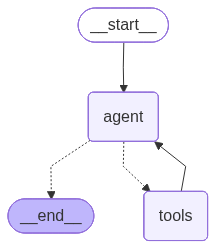

In [9]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## Agent use (invoke)

In [22]:
# response_metadata regarding token_usage : input tokens = size of the questions + context (= system prompt + any additional information), output tokens = size of the answer
result = app.invoke({"messages": [("human", "what is the most beautiful city of the world?")]})
print(result)
print("\n----------------------------------------------\n")
print(result["messages"][-1].content)

{'messages': [HumanMessage(content='what is the most beautiful city of the world?', additional_kwargs={}, response_metadata={}, id='8c2bb8a4-ba70-476c-a401-4d9935cbcf48'), AIMessage(content='Beauty is subjective, and opinions about the most beautiful city in the world vary widely depending on personal preferences, experiences, and cultural background. However, several cities are frequently mentioned for their stunning architecture, landscapes, and cultural significance. Here are a few that often top the lists:\n\n1. **Paris, France** - Known as the "City of Light," Paris is famous for its iconic landmarks like the Eiffel Tower, Notre-Dame Cathedral, and its charming streets.\n\n2. **Venice, Italy** - Renowned for its canals, historic buildings, and art, Venice is often described as enchanting and romantic.\n\n3. **Barcelona, Spain** - With its unique Gaudí architecture, including the Sagrada Família and colorful parks, Barcelona offers a vibrant atmosphere.\n\n4. **Prague, Czech Republ

## Agent use (stream)

In [11]:
# streaming, see https://docs.langchain.com/oss/python/langgraph/streaming
# stream_mode | values = full state snapshot after each step | updates = only the changed keys from each node | messages = (message_chunk, metadata) from LLM calls
for chunk in app.stream({"messages": "what is the most beautiful city of the world?"}, stream_mode="values", version="v2"):
    print(chunk["type"])
    print(chunk["data"])

values
{'messages': [HumanMessage(content='what is the most beautiful city of the world?', additional_kwargs={}, response_metadata={}, id='ce4332a9-82c0-4154-ae09-f318f6867c4c')]}
values
{'messages': [HumanMessage(content='what is the most beautiful city of the world?', additional_kwargs={}, response_metadata={}, id='ce4332a9-82c0-4154-ae09-f318f6867c4c'), AIMessage(content='The title of the "most beautiful city in the world" is subjective and often varies based on personal preferences and criteria. However, several cities frequently appear on lists and are celebrated for their beauty:\n\n1. **Paris, France** - Known for its iconic landmarks like the Eiffel Tower, Louvre Museum, and charming streets.\n2. **Venice, Italy** - Famous for its canals, historic architecture, and romantic ambiance.\n3. **Prague, Czech Republic** - Renowned for its stunning medieval architecture and vibrant atmosphere.\n4. **Florence, Italy** - Celebrated for its Renaissance art and architecture, including the

## Agent use (all questions)

In [29]:
q1 = "what is the most beautiful city of the world?"
q2 = "What is 1+1?"
q3 = "What is today's date?"
q4 = "What is the distance between Dresden and Paris?"
q5 = "Who is Ursula Staudinger?"
q6 = "Does TU Dresden exist and what is it?"
q7 = "What is the weather like in Dresden, Germany?"
q8 = "What is the population of Saxony-Anhalt?"
q9 = "What is the area of Lower-Saxony?"
q10 = "What is the capital of Bavaria?"
q11 = "What are the six closest cities to Dresden in terms of geographic distance. Return their coordinates, the distance in km and the temperature values as geojson. Do not include Dresden."

q12 = "Wer is Ursula Staudinger?"
q13 = "Was is das Wetter in Dresden, Deutschland?"


for chunk in app.stream({"messages": [("human", q12)]}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Wer is Ursula Staudinger?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_zRyOb3dFCTMpIdWNc2UkMjz5)
 Call ID: call_zRyOb3dFCTMpIdWNc2UkMjz5
  Args:
    query: Ursula Staudinger
================================= Tool Message =================================
Name: tavily_search

{"query": "Ursula Staudinger", "response_time": 0.65, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Ursula_Staudinger", "title": "Ursula Staudinger - Wikipedia", "content": "Ursula Marie Staudinger is a German psychologist and researcher of aging. She is the rector of the Technical University of Dresden (TUD).", "score": 0.99993944, "raw_content": null}, {"url": "https://www.ursulastaudinger.com/", "title": "Welcome - Ursula M. Staudinger", "content": "### Für den Frieden. Ursula Staudinger hielt den Le

## Agent testing

Dataset

In [38]:
# The code for agent testing is adapted from https://docs.langchain.com/langsmith/evaluate-llm-application and https://docs.langchain.com/langsmith/evaluate-graph
from langsmith import Client
import uuid # https://docs.python.org/3/library/uuid.html#uuid.UUID

questions = [
    "What is 1+1",
    "What is the weather like in Dresden, Germany?",
    "Does TU Dresden exist and what is it?",
]

answers = [
    "2.",
    "I don't know.",
    "Yes, it is a university."
]

ls_client = Client()

current_uuid = uuid.uuid4()
dataset_name = "my_llm_agent-"+str(current_uuid) # names should be unique, so we create a new name each time
dataset = ls_client.create_dataset(dataset_name=dataset_name)

ls_client.create_examples(
    inputs=[{"question": q} for q in questions],
    outputs=[{"answer": a} for a in answers],
    dataset_id=dataset.id)

{'example_ids': ['39154167-6ad1-44c4-920b-9740ea68b38d',
  'ae0f7851-2836-4a18-8f01-4cb71f389cc5',
  'de46b1fb-b163-49bd-adb2-74fb1cb93c54'],
 'count': 3,
 'as_of': '2026-04-17T10:01:16.198234419Z'}

Evaluator

In [39]:
from langchain.chat_models import init_chat_model

judge_llm = init_chat_model("gpt-4.1")

async def correct(outputs: dict, reference_outputs: dict) -> bool:
    # outputs and reference_outputs seem to be reserved keywords as of April 2026
    '''
    return outputs["messages"][-1].content == reference_outputs["answer"]
    '''

    instructions = (
        "Given an actual answer and an expected answer, determine whether"
        " the actual answer contains all of the information in the"
        " expected answer. Respond with 'CORRECT' if the actual answer"
        " does contain all of the expected information and 'INCORRECT'"
        " otherwise. Do not include anything else in your response."
    )
    # Our graph outputs a State dictionary, which in this case means
    # we'll have a 'messages' key and the final message should
    # be our actual answer.
    actual_answer = outputs["messages"][-1].content
    expected_answer = reference_outputs["answer"]
    user_msg = (
        f"ACTUAL ANSWER: {actual_answer}"
        f"\n\nEXPECTED ANSWER: {expected_answer}"
    )
    response = await judge_llm.ainvoke(
        [
            {"role": "system", "content": instructions},
            {"role": "user", "content": user_msg}
        ]
    )
    return response.content.upper() == "CORRECT"


Run Evaluations

In [ ]:
from langsmith import aevaluate # you can use aevaluate for asynchronous evaluation when there are lots of examples to test. Else evaluate is fine as well

def reformat_input (inputs: dict) -> dict:
  return {"messages": [{"role": "user", "content": inputs['question']}]}

# We use LCEL declarative syntax here: langgraph graphs are also langchain runnables.
# We need to reformat the input, because the agent expects the format '{"messages": [("human", "what is the most beautiful city of the world?")]}'
ai_model = reformat_input | app

# optional, used to populate model/prompt/tool columns in UI
EXPERIMENT_METADATA = {
"models": "openAI:gpt-4.1",
"tools": [{"name": "get_weather", "description": "API call to get the current weather."},
          {"name": "search_engine", "description": "A tavily search engine."}]}

async def main():
    experiment_results = await aevaluate(
        ai_model,
        data=dataset_name,
        evaluators=[correct],
        max_concurrency=4,  # optional
        experiment_prefix="llm-evaluation-101-gpt-4.1",  # optional
        metadata=EXPERIMENT_METADATA
    )
    #print(experiment_results)

await main()
print("Done")